In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

# Lepsza metryka
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
data = load_iris()

X, y = data.data, data.target

# Sprawdzam ile cech ma iris
print(X.shape) 

(150, 4)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# Zmiana klas na categorical, czyli w formie, np. (0,0,1)
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [6]:
# Dałem shape do pierwszej warstwy (za "relu"), ale wyczytałem, że określa się liczbę cech przed warstwami. Wcześniej wyskakiwało mi ostrzeżenie.

model = Sequential([
    tf.keras.Input(shape=(4,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
learn = model.fit(X_train, y_train, epochs=100, validation_split=0.2, batch_size=8)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2188 - loss: 1.3535 - val_accuracy: 0.2500 - val_loss: 1.3487
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2812 - loss: 1.2313 - val_accuracy: 0.3333 - val_loss: 1.2442
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3229 - loss: 1.1513 - val_accuracy: 0.2917 - val_loss: 1.1714
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3438 - loss: 1.0917 - val_accuracy: 0.3333 - val_loss: 1.1236
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3229 - loss: 1.0461 - val_accuracy: 0.3750 - val_loss: 1.0838
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3750 - loss: 1.0012 - val_accuracy: 0.3750 - val_loss: 1.0514
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4479 - loss: 0.9624 - val_accuracy: 0.4167 - val_loss: 1.0232
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.9258 - val_accuracy: 0.4167 - 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9750 - loss: 0.0691  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9667 - loss: 0.0983
Accuracy TRAIN: 0.9750000238418579
Loss TRAIN : 0.06911611557006836
Accuracy TEST: 0.9666666388511658
Loss TEST: 0.09827741235494614


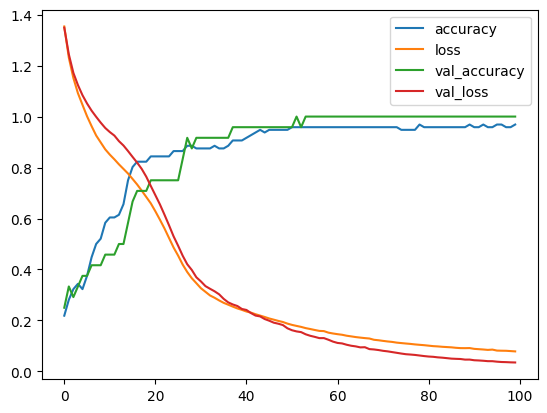

In [9]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

pd.DataFrame(learn.history).plot()

print("Accuracy TRAIN:", train_acc)
print("Loss TRAIN :", train_loss)
print("Accuracy TEST:", test_acc)
print("Loss TEST:", test_loss)

Widać, że model osiągnał dobre wyniki na danych treningowych i testowych. Nie widać overfittingu. 

In [10]:
prediction = model.predict(X_test)

print(prediction[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[9.9921715e-01 6.1179232e-04 1.7106404e-04]
 [8.4364548e-04 1.3914900e-01 8.6000735e-01]
 [1.9304333e-02 9.7425848e-01 6.4371708e-03]
 [3.3354042e-03 9.9380881e-01 2.8557540e-03]
 [9.9951482e-01 3.2555862e-04 1.5971073e-04]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



<Axes: >

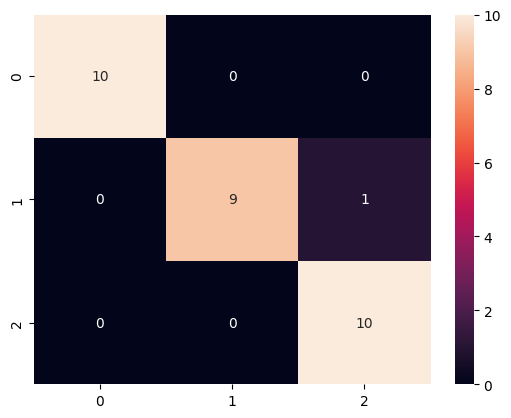

In [11]:
y_pred = np.argmax(prediction, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

Macierz pomyłek pokazuje, że model poprawnie określał większość danych. Wystąpił jeden błąd dla klasy 1, którą przypisano do klasy 2.
Wartości classification report (precision, recall, f1-score) są wysokie, co oznacza, że model dobrze rozpoznaje klasy i rzadko popełnia błędy.